In [1]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

# --- Specify your targets ---
BASELINE_SWEEP_PATH = "jdm8943-rochester-institute-of-technology/style-prompt-gen/jrawx2mz"  


# Baseline — aggregate finished runs from baseline sweep
baseline_sweep = api.sweep(BASELINE_SWEEP_PATH)
baseline_rows = []
for br in baseline_sweep.runs:
    if br.state != "finished":
        continue
    baseline_rows.append({
        "meteor":       br.summary.get("meteor_mean"),
        "bertscore_f1": br.summary.get("bertscore_f1_mean"),
        "chrf_mean":    br.summary.get("chrf_mean"),
        "chrf_std":     br.summary.get("chrf_std"),
    })
baseline_df = pd.DataFrame(baseline_rows).dropna(how="all")
baseline = {k: baseline_df[k].mean() for k in baseline_df.columns}
print(f"Baseline aggregated from {len(baseline_df)} run(s): {baseline}")



Baseline aggregated from 9 run(s): {'meteor': np.float64(0.287165740753194), 'bertscore_f1': np.float64(0.900257925192515), 'chrf_mean': np.float64(0.39022078420643386), 'chrf_std': np.float64(0.1237557606838761)}
              run_name data_source meteor meteor_std bertscore_f1  \
0         wild-sweep-5        None   None       None         None   
1     ethereal-sweep-6        None   None       None         None   
2       devout-sweep-7        None   None       None         None   
3      astral-sweep-11        None   None       None         None   
4     stellar-sweep-13        None   None       None         None   
5       sleek-sweep-14        None   None       None         None   
6        good-sweep-15        None   None       None         None   
7        rich-sweep-16        None   None       None         None   
8   celestial-sweep-17        None   None       None         None   
9        rich-sweep-18        None   None       None         None   
10     lively-sweep-19     

In [6]:

SWEEP_PATH          = "jdm8943-rochester-institute-of-technology/sweep-style-prompt-gen/duhwnuvy"
sweep = api.sweep(SWEEP_PATH)
sweep_rows = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))

    # fold_metrics = {"vec_std": [], "mean_cosine_sim": []}
    # for k in range(5):
    #     for m in fold_metrics:
    #         v = run.summary.get(f"fold_{k}/{m}")
    #         if v is not None:
    #             fold_metrics[m].append(float(v))
    sweep_rows.append({
        "run_name":               run.name,
        "data_source":              run.config.get("data_source"),
        "meteor":                 run.summary.get("trials/mean_meteor"),
        "meteor_std":             run.summary.get("trials/std_meteor"),
        "bertscore_f1":           run.summary.get("trials/mean_bertscore_f1"),
        "bertscore_f1_std":       run.summary.get("trials/std_bertscore_f1"),
        "chrf":                   run.summary.get("trials/mean_chrf"),
        "chrf_std":               run.summary.get("trials/std_chrf")
    })


sweep_df = pd.DataFrame(sweep_rows).sort_values("data_source").reset_index(drop=True)
print(sweep_df)

         run_name data_source    meteor  meteor_std  bertscore_f1  \
0  fluent-sweep-1        both  0.464439    0.039002      0.903388   
1   laced-sweep-3    expresso  0.205638    0.003797      0.881495   
2  honest-sweep-2   styletalk  0.120141    0.005192      0.832178   

   bertscore_f1_std      chrf  chrf_std  
0          0.011059  0.519692  0.025314  
1          0.003639  0.257578  0.006446  
2          0.003666  0.195123  0.009033  


In [7]:
FIGURE_OUTPUT = "results_figures"

In [ ]:
REPORT_KEYS = [
    "dropout", "n_folds", "num_turns", "weight_decay",
    "learning_rate", "num_unfrozen_embedder_layers",
]

print(f"{'='*70}")
print(f"SWEEP RESULTS REPORT")
print(f"{'='*70}")

for sweep_run in sorted(sweep.runs, key=lambda r: (r.summary.get("test/meteor") or 0), reverse=True):
    if sweep_run.state != "finished":
        continue
    meteor = sweep_run.summary.get("test/meteor")
    cfg_lines = "  " + "\n  ".join(
        f"{k}: {sweep_run.config.get(k, 'N/A')}" for k in REPORT_KEYS
    )
    print(f"\nRun: {sweep_run.name}")
    print(f"Config:\n{cfg_lines}")
    print(f"METEOR: {meteor:.4f}" if meteor is not None else "METEOR: N/A")
    print(f"{'-'*70}")

print(f"\nBaseline ({single_run.name})")
print(f"METEOR: {baseline['meteor']:.4f}" if baseline['meteor'] is not None else "METEOR: N/A")
print(f"{'='*70}")


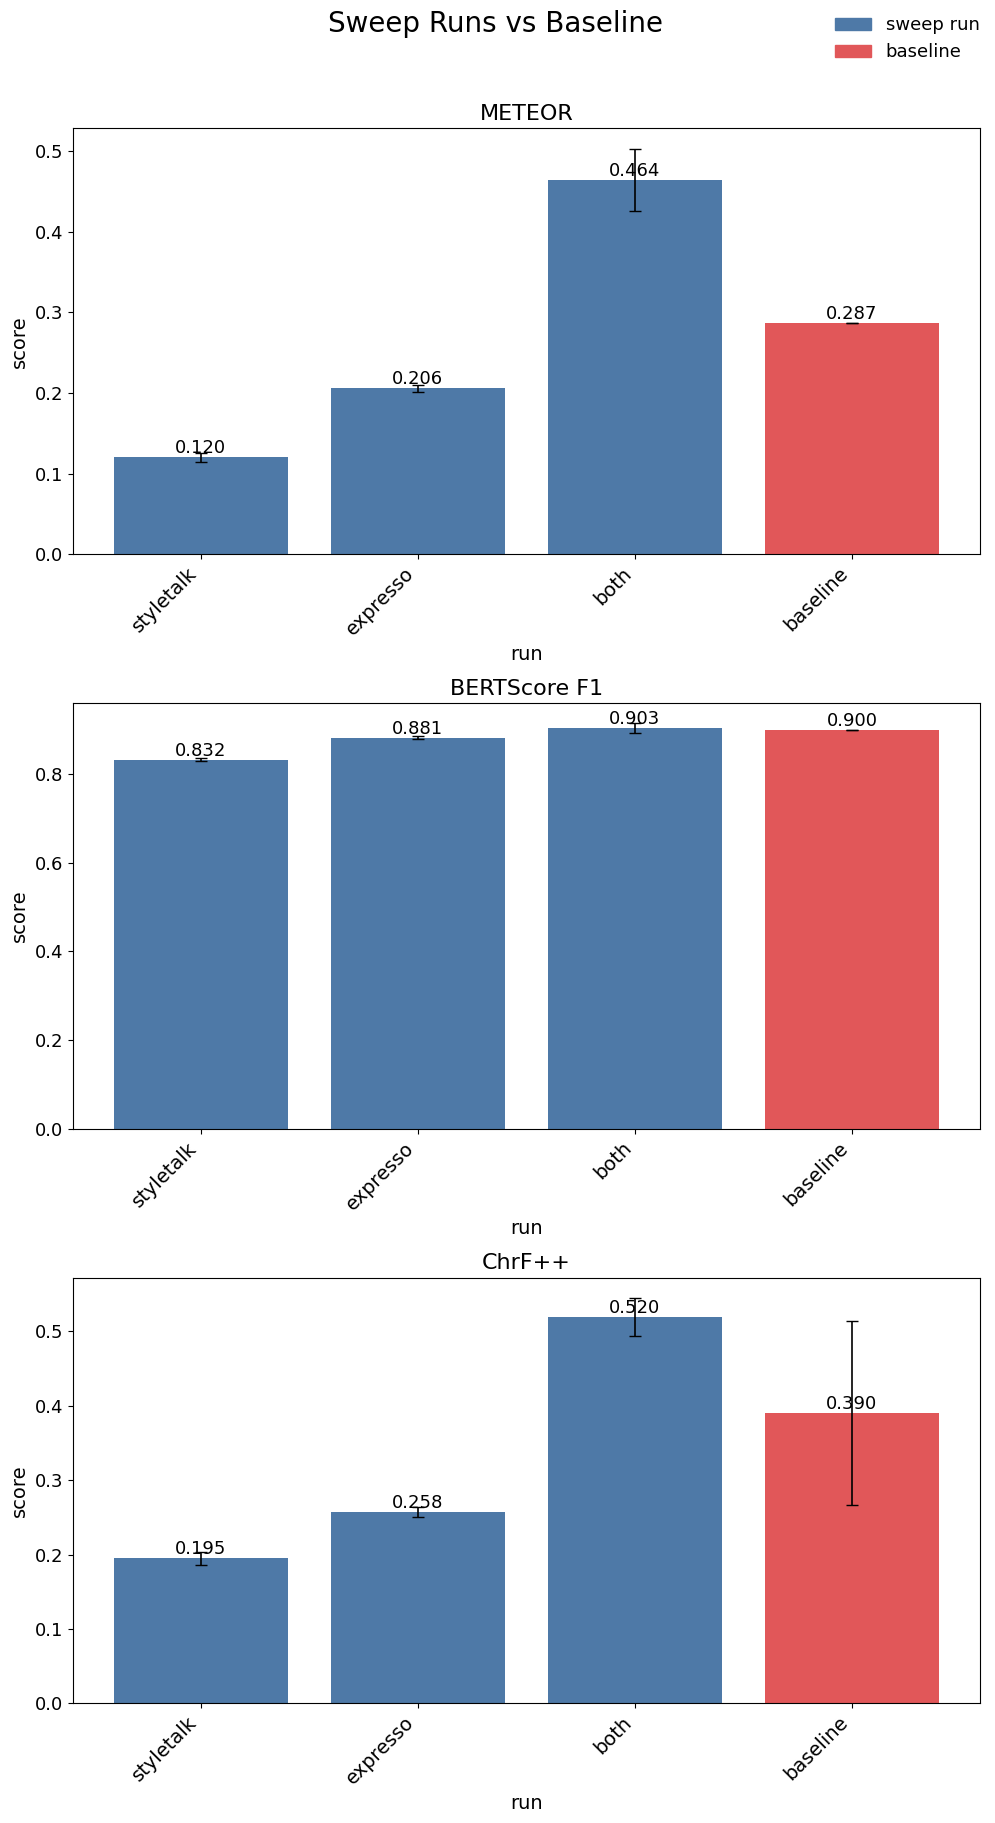

In [20]:
BASELINE_COLOR = "#e15759"
SWEEP_COLOR    = "#4e79a7"

fig, axes = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle("Sweep Runs vs Baseline", fontsize=20, y=1.01)

def bar_with_baseline(ax, sweep_df, mean_col, std_col, baseline_mean, baseline_std, ylabel, title):
    sweep_labels = list(sweep_df["data_source"])
    sweep_means  = list(sweep_df[mean_col])
    sweep_stds   = list(sweep_df[std_col]) if std_col in sweep_df else [None] * len(sweep_means)

    order        = sorted(range(len(sweep_means)), key=lambda i: sweep_means[i] if sweep_means[i] is not None else float("inf"))
    sweep_labels = [sweep_labels[i] for i in order]
    sweep_means  = [sweep_means[i]  for i in order]
    sweep_stds   = [sweep_stds[i]   for i in order]

    labels = sweep_labels + ["baseline"]
    means  = sweep_means  + [baseline_mean]
    stds   = sweep_stds   + [baseline_std]
    colors = [SWEEP_COLOR] * len(sweep_df) + [BASELINE_COLOR]

    bars = ax.bar(range(len(labels)), means, color=colors)
    ax.errorbar(
        range(len(labels)),
        means,
        yerr=[s if s is not None else 0 for s in stds],
        fmt="none", color="black", capsize=4, linewidth=1.2,
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("run", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, means):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)


bar_with_baseline(axes[0], sweep_df, "meteor",       "meteor_std",       baseline["meteor"],       baseline.get("meteor_std"),       "score", "METEOR")
bar_with_baseline(axes[1], sweep_df, "bertscore_f1", "bertscore_f1_std", baseline["bertscore_f1"], baseline.get("bertscore_f1_std"), "score", "BERTScore F1")
bar_with_baseline(axes[2], sweep_df, "chrf",         "chrf_std",         baseline["chrf_mean"],    baseline.get("chrf_std"),         "score", "ChrF++")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=SWEEP_COLOR, label="sweep run"),
                    Patch(color=BASELINE_COLOR, label="baseline")],
           loc="upper right", frameon=False, fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(FIGURE_OUTPUT + "/" + "sweep_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


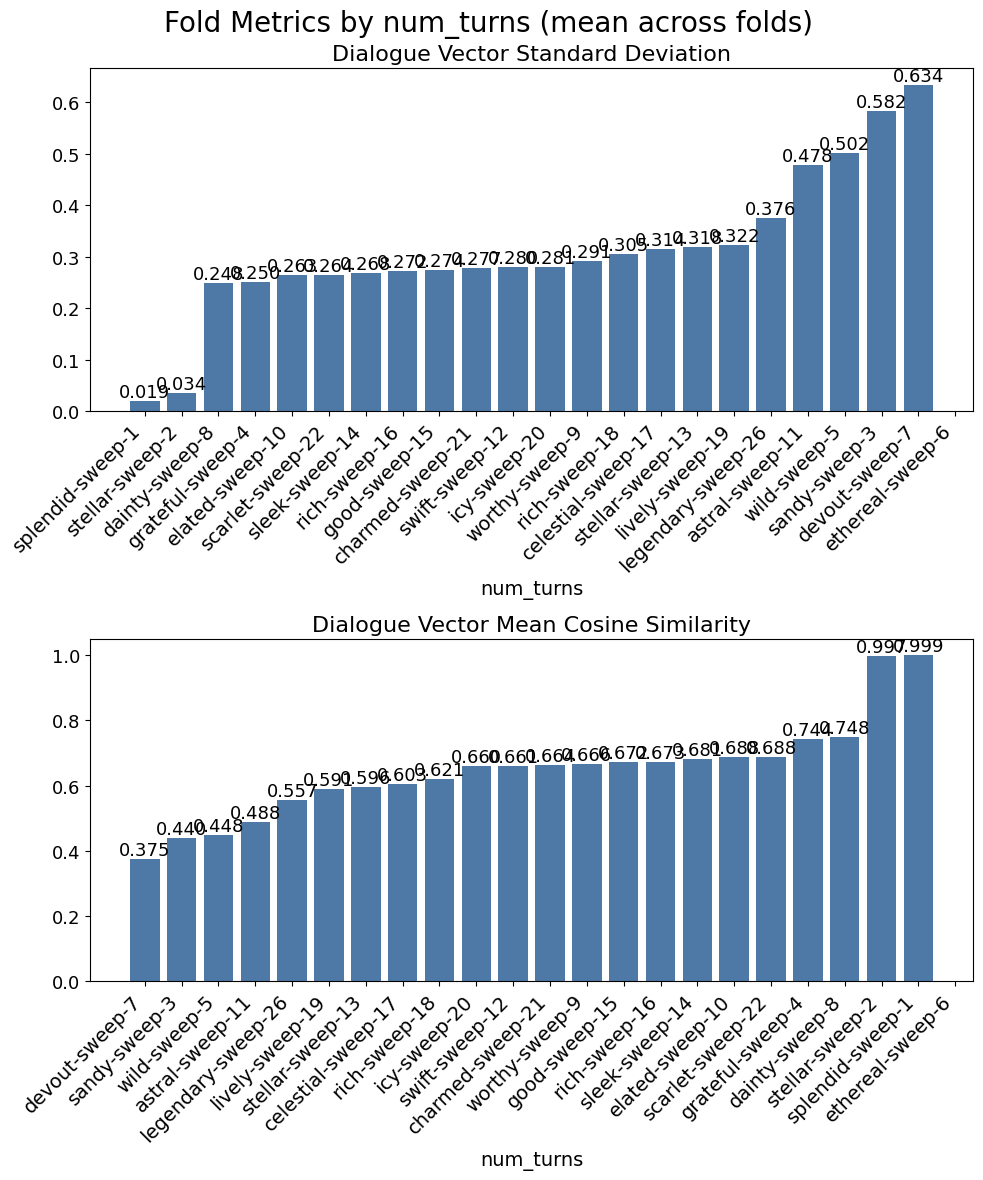

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

fig.suptitle("Fold Metrics by num_turns (mean across folds)", fontsize=20)

fold_metrics_cfg = [
    ("fold_vec_std",         "Dialogue Vector Standard Deviation"),
    ("fold_mean_cosine_sim", "Dialogue Vector Mean Cosine Similarity"),
]

for ax, (col, title) in zip(axes, fold_metrics_cfg):
    means = [np.mean([float(v) for v in vals]) if vals else float("nan") for vals in sweep_df[col]]
    labels = [str(t) for t in sweep_df["run_name"]]

    order = sorted(range(len(means)), key=lambda i: means[i] if not np.isnan(means[i]) else float("inf"))
    means = [means[i] for i in order]
    labels = [labels[i] for i in order]



    bars = ax.bar(range(len(labels)), means, color=SWEEP_COLOR)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("num_turns", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, means):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT + "/" + "fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

Detected  power='system.gpu.0.powerWatts'  memory='system.gpu.0.memoryAllocatedBytes'
Available system columns: ['system.gpu.0.correctedMemoryErrors', 'system.gpu.0.enforcedPowerLimitWatts', 'system.gpu.0.gpu', 'system.gpu.0.memory', 'system.gpu.0.memoryAllocated', 'system.gpu.0.memoryAllocatedBytes', 'system.gpu.0.memoryClock', 'system.gpu.0.powerPercent', 'system.gpu.0.powerWatts', 'system.gpu.0.smClock', 'system.gpu.0.temp', 'system.gpu.0.uncorrectedMemoryErrors']


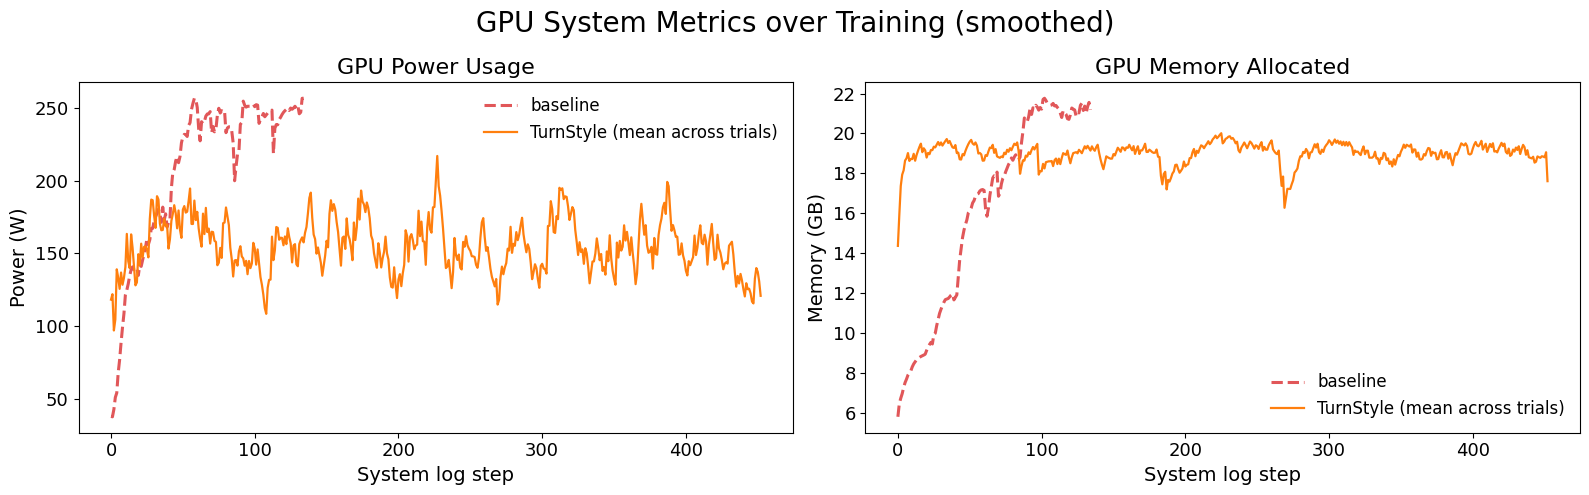

In [17]:
import numpy as np

SMOOTH_SPAN = 10  # lower = less smoothing, higher = more


# W&B system metric column names vary by driver version — search by substring fallback
def find_col(df, keywords):
    for col in df.columns:
        if all(k in col.lower() for k in keywords):
            return col
    return None

def smooth(s, span=SMOOTH_SPAN):
    return s.dropna().reset_index(drop=True).ewm(span=span, min_periods=1).mean()

# --- fetch system histories ---
# baseline: average system history across finished baseline sweep runs
baseline_sys_frames = []
for br in baseline_sweep.runs:
    if br.state != "finished":
        continue
    run = api.run("/".join(br.path))
    df  = pd.DataFrame(run.history(stream="system"))
    if not df.empty:
        baseline_sys_frames.append(df)

if baseline_sys_frames:
    # align by step index and average
    baseline_sys = pd.concat(baseline_sys_frames).groupby(level=0).mean()
else:
    baseline_sys = pd.DataFrame()

sys_data = {"baseline": baseline_sys}

sys_data = {"baseline": baseline_sys}

sweep_sys_frames = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))
    df  = pd.DataFrame(run.history(stream="system"))
    if not df.empty:
        sweep_sys_frames.append(df)

if sweep_sys_frames:
    sys_data["TurnStyle (mean across trials)"] = pd.concat(sweep_sys_frames).groupby(level=0).mean()



# detect column names from first non-empty df
first_df  = next(df for df in sys_data.values() if not df.empty)
power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocatedBytes"

if mem_col is None:
    mem_col = find_col(first_df, ["memory"])
print(f"Detected  power={power_col!r}  memory={mem_col!r}")
print("Available system columns:", [c for c in first_df.columns if "gpu" in c.lower()])

# --- colors ---
palette  = list(plt.cm.tab10.colors)
labels   = list(sys_data.keys())
colors   = {label: palette[i % 10] for i, label in enumerate(labels)}
colors["baseline"] = BASELINE_COLOR

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("GPU System Metrics over Training (smoothed)", fontsize=20)

for label, df in sys_data.items():
    lw = 2.2 if label == "baseline" else 1.6
    ls = "--" if label == "baseline" else "-"

    if power_col and power_col in df.columns:
        s = smooth(df[power_col])
        axes[0].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

    if mem_col and mem_col in df.columns:
        s = smooth(df[mem_col])
        if s.max() > 1e6:
            s = s / 1e9
        axes[1].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

axes[0].set_title("GPU Power Usage", fontsize=16)
axes[0].set_xlabel("System log step", fontsize=14)
axes[0].set_ylabel("Power (W)", fontsize=14)
axes[0].tick_params(labelsize=13)
axes[0].legend(fontsize=12, frameon=False)

axes[1].set_title("GPU Memory Allocated", fontsize=16)
axes[1].set_xlabel("System log step", fontsize=14)
axes[1].set_ylabel("Memory (GB)", fontsize=14)
axes[1].tick_params(labelsize=13)
axes[1].legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_OUTPUT + "/" + "system_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
# unit test for compute_tag_f1
import sys, json
sys.path.insert(0, "..")
from model.train_helpers import compute_tag_f1

with open("baseline_outputs_sample.json") as f:
    samples = json.load(f)

preds = [s["prediction"].removeprefix("Style: ").strip() for s in samples]
refs  = [s["ground_truth"].strip() for s in samples]

results = compute_tag_f1(preds, refs, test_dataset_source="expresso")

print(f"{'Metric':<35} {'Mean':>8}  {'Std':>8}")
print("-" * 55)
for k, v in sorted(results.items()):
    print(f"{k:<35} {v:>8.4f}")

Metric                                  Mean       Std
-------------------------------------------------------
tag_f1_accent_mean                    0.7826
tag_f1_accent_std                     0.4125
tag_f1_gender_mean                    0.5652
tag_f1_gender_std                     0.4957
tag_f1_intrinsic_tags_mean            0.6201
tag_f1_intrinsic_tags_std             0.2738
tag_f1_noise_mean                     0.2609
tag_f1_noise_std                      0.4391
tag_f1_overall_mean                   0.5881
tag_f1_overall_std                    0.2454
tag_f1_pitch_mean                     0.8261
tag_f1_pitch_std                      0.3790
tag_f1_speaking_rate_mean             0.4348
tag_f1_speaking_rate_std              0.4957
